Emissions Step 1 — Derive the co2_kg column

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# Emissions Step 1: derive CO2 and cost from electricity
df = pd.read_parquet("model_ready_clean.parquet")   # site-0 units already fixed -> true kWh

# central published factors (with a sensitivity band we'll use in Step 2)
EMISSION_FACTOR = 0.40   # kg CO2 per kWh  (~US EPA eGRID national average)
TARIFF          = 0.15   # US$ per kWh

# derive the two columns — THIS is the carbon layer
df["co2_kg"]   = df["meter_reading"] * EMISSION_FACTOR
df["cost_usd"] = df["meter_reading"] * TARIFF

# headline totals across the whole dataset
total_kwh    = df["meter_reading"].sum()
total_co2_t  = df["co2_kg"].sum() / 1000      # kg -> tonnes
total_cost_m = df["cost_usd"].sum() / 1e6     # -> millions US$

print(f"total electricity : {total_kwh/1e6:,.1f} million kWh")
print(f"total CO2         : {total_co2_t:,.0f} tonnes")
print(f"total cost        : ${total_cost_m:,.1f} million")
df[["building_id", "timestamp", "meter_reading", "co2_kg", "cost_usd"]].head(3)


total electricity : 1,786.5 million kWh
total CO2         : 714,587 tonnes
total cost        : $268.0 million


,building_id,timestamp,meter_reading,co2_kg,cost_usd
0,0,2016-05-27 18:00:00,52.415363,20.966146,7.862305
1,0,2016-05-27 19:00:00,51.615204,20.646082,7.742281
2,0,2016-05-27 20:00:00,51.815098,20.726040,7.772265


Emissions Step 2 — The sensitivity band (low / central / high)

In [3]:
# Emissions Step 2: sensitivity band for CO2 and cost
total_kwh = df["meter_reading"].sum()

emission_factors = {"low (clean grid)": 0.20, "central": 0.40, "high (dirty grid)": 0.50}
tariffs          = {"low": 0.10, "central": 0.15, "high": 0.25}

co2_band  = {k: total_kwh * f / 1000 for k, f in emission_factors.items()}   # tonnes
cost_band = {k: total_kwh * t / 1e6  for k, t in tariffs.items()}            # million $

band = pd.DataFrame({
    "CO2 (tonnes)":  pd.Series(co2_band).round(0),
    "Cost (M US$)":  pd.Series(cost_band).round(1),
})
print(band)


                   CO2 (tonnes)  Cost (M US$)
central                714587.0    268.000000
high                        NaN    446.600006
high (dirty grid)      893234.0           NaN
low                         NaN    178.600006
low (clean grid)       357293.0           NaN


In [4]:
# Emissions Step 2 (tidy): aligned sensitivity band
total_kwh = df["meter_reading"].sum()

band = pd.DataFrame({
    "emission_factor (kg/kWh)": [0.20, 0.40, 0.50],
    "CO2 (tonnes)": [total_kwh * f / 1000 for f in (0.20, 0.40, 0.50)],
    "tariff ($/kWh)": [0.10, 0.15, 0.25],
    "Cost (M US$)": [total_kwh * t / 1e6 for t in (0.10, 0.15, 0.25)],
}, index=["low", "central", "high"]).round({"CO2 (tonnes)": 0, "Cost (M US$)": 1})

print(band)


         emission_factor (kg/kWh)  CO2 (tonnes)  tariff ($/kWh)  Cost (M US$)
low                           0.2      357293.0            0.10    178.600006
central                       0.4      714587.0            0.15    268.000000
high                          0.5      893234.0            0.25    446.600006


Emissions Step 3 — CO₂ by month and by building type

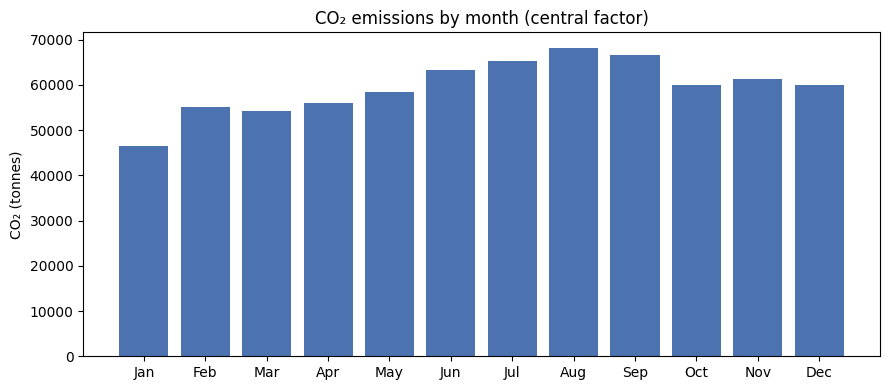

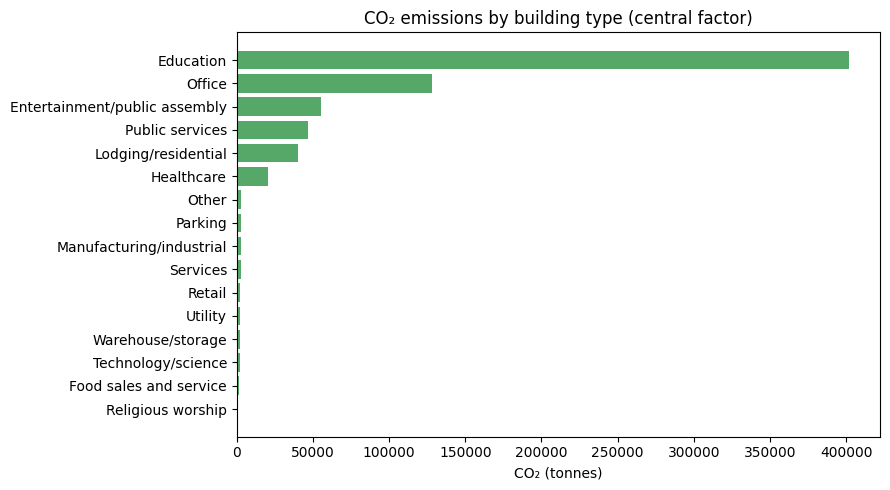

CO₂ by month (tonnes):
 month
1     46500.0
2     55028.0
3     54131.0
4     56034.0
5     58359.0
6     63371.0
7     65179.0
8     68183.0
9     66679.0
10    60024.0
11    61184.0
12    59917.0
Name: co2_kg, dtype: float32

Top 5 building types by CO₂ (tonnes):
 primary_use
Education                        402063.0
Office                           128033.0
Entertainment/public assembly     55307.0
Public services                   46532.0
Lodging/residential               40051.0
Name: co2_kg, dtype: float32


In [5]:
# Emissions Step 3: emissions charts (central factor)
# --- CO2 by month (tonnes) ---
co2_by_month = df.groupby("month")["co2_kg"].sum() / 1000
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(9, 4))
plt.bar(range(1, 13), co2_by_month.values, color="#4C72B0")
plt.xticks(range(1, 13), month_labels)
plt.title("CO₂ emissions by month (central factor)")
plt.ylabel("CO₂ (tonnes)")
plt.tight_layout()
plt.show()

# --- CO2 by building type (tonnes) ---
co2_by_use = (df.groupby("primary_use", observed=True)["co2_kg"].sum() / 1000
                ).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(co2_by_use.index, co2_by_use.values, color="#55A868")
plt.gca().invert_yaxis()
plt.title("CO₂ emissions by building type (central factor)")
plt.xlabel("CO₂ (tonnes)")
plt.tight_layout()
plt.show()

print("CO₂ by month (tonnes):\n", co2_by_month.round(0))
print("\nTop 5 building types by CO₂ (tonnes):\n", co2_by_use.head(5).round(0))


Emissions Step 4 — Forecast-driven savings 

In [6]:
# Emissions Step 4: CO2 & cost avoided by forecast-driven automation
total_kwh_year = df["meter_reading"].sum()

savings = pd.DataFrame(
    [(s, total_kwh_year * s / 1e6,                    # kWh saved (millions)
         total_kwh_year * s * 0.40 / 1000,            # CO2 saved (tonnes) @ central factor
         total_kwh_year * s * 0.15 / 1e6)             # cost saved (M US$) @ central tariff
     for s in (0.05, 0.10, 0.15)],
    columns=["savings_frac", "kWh saved (M)", "CO2 avoided (tonnes)", "Cost avoided (M US$)"],
    index=["low (5%)", "central (10%)", "high (15%)"],
).round(1)

print(savings)
print(f"\nCentral estimate: forecast-driven automation could avoid "
      f"{total_kwh_year*0.10*0.40/1000:,.0f} tonnes CO₂ and "
      f"${total_kwh_year*0.10*0.15/1e6:,.1f}M per year.")


               savings_frac  kWh saved (M)  CO2 avoided (tonnes)  \
low (5%)                0.0      89.300003          35729.300781   
central (10%)           0.1     178.600006          71458.703125   
high (15%)              0.2     268.000000         107188.000000   

               Cost avoided (M US$)  
low (5%)                  13.400000  
central (10%)             26.799999  
high (15%)                40.200001  

Central estimate: forecast-driven automation could avoid 71,459 tonnes CO₂ and $26.8M per year.
